## Random Forests with Python

The Python code in this Notebook is provided as part of a **[Dave on Data](https://www.daveondata.com)** YouTube crash course on random forests with Python.

This code is provided **as-is** for your use. No warranty for this code should be assumed or implied.

### Load the *Adult Census* Dataset

In [3]:
import pandas as pd

adult_train = pd.read_csv('adult_train.csv')
adult_train.head()

,Age,WorkClass,Fnlwgt,Education,EducationNum,MaritalStatus,Occupation,Relationship,Race,Sex,CapitalGain,CapitalLoss,HoursPerWeek,NativeCountry,Label
0,20,Private,30035,Assoc-acdm,12,Never-married,Sales,Own-child,White,Female,0,0,40,United-States,<=50K
1,22,Private,141297,Some-college,10,Never-married,Tech-support,Own-child,White,Male,0,0,40,United-States,<=50K
2,63,Private,440607,Preschool,1,Married-civ-spouse,Prof-specialty,Husband,Other,Male,0,0,30,Mexico,<=50K
3,32,Private,165949,Bachelors,13,Divorced,Machine-op-inspct,Not-in-family,White,Female,0,1590,42,United-States,<=50K
4,36,Private,139743,Some-college,10,Widowed,Prof-specialty,Own-child,White,Female,0,0,40,United-States,<=50K


### Prepare Features

In [4]:
# Add a new Female feature to the DataFrame
adult_train['Female'] = adult_train['Sex'].replace({'Female': 1, 'Male': 0})

# Features to use to predict the labels
all_features = ['Age', 'EducationNum', 'MaritalStatus', 'Occupation', 'Race', 
                'Female', 'CapitalGain', 'CapitalLoss', 'HoursPerWeek']

# Categorical features
cat_features = ['MaritalStatus', 'Occupation', 'Race']

# Select the above features and one-hot encode Occupation
adult_X = pd.get_dummies(adult_train[all_features], prefix = cat_features , 
                         columns = cat_features)
adult_X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15016 entries, 0 to 15015
Data columns (total 32 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Age                                  15016 non-null  int64
 1   EducationNum                         15016 non-null  int64
 2   Female                               15016 non-null  int64
 3   CapitalGain                          15016 non-null  int64
 4   CapitalLoss                          15016 non-null  int64
 5   HoursPerWeek                         15016 non-null  int64
 6   MaritalStatus_Divorced               15016 non-null  bool 
 7   MaritalStatus_Married-AF-spouse      15016 non-null  bool 
 8   MaritalStatus_Married-civ-spouse     15016 non-null  bool 
 9   MaritalStatus_Married-spouse-absent  15016 non-null  bool 
 10  MaritalStatus_Never-married          15016 non-null  bool 
 11  MaritalStatus_Separated              15016 non-null  b

### Encode Labels

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
adult_y = label_encoder.fit_transform(adult_train['Label'])

print(label_encoder.classes_)
print(adult_y)

['<=50K' '>50K']
[0 0 0 ... 1 1 1]


### Train a Mighty Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Instatiate the Random Forest object
adult_rf = RandomForestClassifier(n_estimators = 200, oob_score = True, 
                                  n_jobs = 2, random_state = 12345)

# Train the RandomForestClassifier
adult_rf.fit(adult_X, adult_y)

# What is the accuracy estimate?
print(f'Estimated accuracy with OOB data: {adult_rf.oob_score_:.4f}')

# What is the accuracy on the training data?
print(f'Training data accuracy: {adult_rf.score(adult_X, adult_y):.4f}')

Estimated accuracy with OOB data: 0.8135
Training data accuracy: 0.9638


### Get OOB Predictions

In [8]:
# Get the out-of-bag (OOB) predictions as a DataFrame
oob_preds = pd.DataFrame(adult_rf.oob_decision_function_, 
                         columns = label_encoder.classes_)

# Create a new column for the label prediction
oob_preds['Label'] = 0

# Set label for >50K if a prediction is greater than 50% 
oob_preds.loc[oob_preds['>50K'] > 0.5, 'Label'] = 1 

print(oob_preds.shape)
print(oob_preds.head(n = 10))

(15016, 3)
      <=50K      >50K  Label
0  1.000000  0.000000      0
1  0.987654  0.012346      0
2  0.666667  0.333333      0
3  0.780952  0.219048      0
4  0.865854  0.134146      0
5  0.376471  0.623529      1
6  0.971831  0.028169      0
7  1.000000  0.000000      0
8  0.840000  0.160000      0
9  0.606838  0.393162      0


### Visualize OOB Predictions

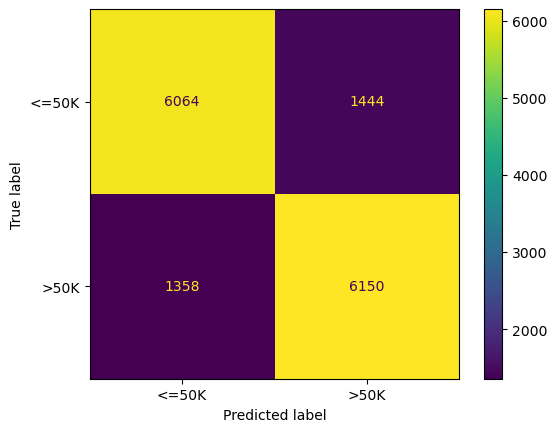

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Visualize OOB predictions using a confusion matrix
cm = confusion_matrix(adult_y, oob_preds['Label'])
cmd = ConfusionMatrixDisplay(cm, display_labels = label_encoder.classes_)
cmd.plot();